1️⃣ **Définition du problème**\
2️⃣ **Collection des données (Data Collection)**\
3️⃣ **Compréhension & exploration des données (EDA)**\
- Structure des données
- Types de variables
- Valeurs manquantes
- Corrélations
- Visualisations

4️⃣ **Modélisation avec Pyacaret** `setup()`/`compare_model()`...

### **I. Importation des bibliothéques**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pycaret.regression import *

### **II. Exploration de donnée**

#### **1. Importation de donnée**

In [2]:
data = pd.read_excel('../data/insurance.xlsx')
data.head()

,age,genre,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Information de donnée**

In [3]:
print(data.shape) # Dimenssion de donnée
print(data.info())

(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   genre     1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


#### **2. Etude des variables**

In [4]:
data.columns

Index(['age', 'genre', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

**Signification et noms plus courts**
1. **age** : âge de la personne (en années)
2. **sex** : sexe de la personne
3. **bmi (Body Mass Index)** : indice de masse corporelle, qui mesure la corpulence d’un individu:
*Formule*: bmi = $\frac{poids (kg)}{(taille (m))^2}$
4. **children** : nombre d’enfants à charge
5. **smoker** : indique si la personne fume ou non (yes / no)
6. **region** : région géographique de résidence
7. **charges** : montant des frais médicaux

**Objectif d'étude** : *Prédire le montant des frais médicaux (charges) d’un assuré à partir de ses caractéristiques personnelles et de son mode de vie*

#### **3. Description des données**

In [5]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
(data['genre'].value_counts())/data.shape[0]*100

genre
male      50.523169
female    49.476831
Name: count, dtype: float64

In [8]:
print('-------------------les valeurs manquantes------------------')
print(data.isna().sum())
print('\n----------------------Les doublons-------------------------')
data.duplicated().sum()

-------------------les valeurs manquantes------------------
age         0
genre       0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

----------------------Les doublons-------------------------


1

**Définition de doublon:** une ligne de données identique à une autre (erreur de frappe, d’une mauvaise saisie)
**Quand on détecte un doublon dans un dataset, deux stratégies sont possibles**:
- Supprimer la ligne
- Remplacer les valeurs par la moyenne ou la médiane
1. Quand utiliser la SUPPRESSION des doublons ?
=> Quand la ligne répétée ne t’apporte rien et beaucoup de nombre d'observation
2. Quand utiliser le REMPLACEMENT (moyenne/médiane) ?
=> Qand la ligne contient une petite variation et que tu veux garder l’information.

**Interpretation**:Dans notre cas, nous allons supprimer les doublons, car le nombre d'observations est suffisamment élevé pour que cette suppression n'entraîne pas de perte d'information significative.

In [9]:
print('-----------------SUPPRESSION DES DOUBLON------------------')
data = data.drop_duplicates()
data.duplicated().sum()

-----------------SUPPRESSION DES DOUBLON------------------


0

#### **4. Visualisation**

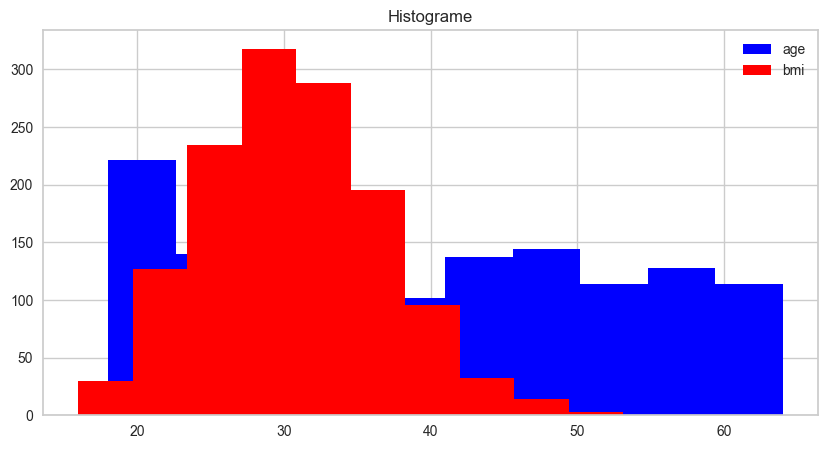

In [12]:
plt.figure(figsize=(10,5))
plt.hist(data['age'],label='age',color='blue')
plt.hist(data['bmi'],label='bmi',color='red') # pie difficile a interpreté
plt.title('Histograme')
plt.legend()
plt.show()

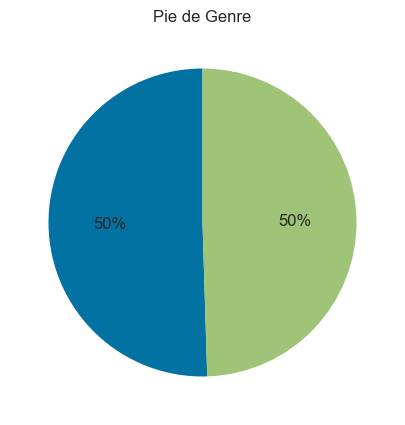

In [14]:
plt.figure(figsize=(10,5))
plt.pie(data['genre'].value_counts(), autopct='%1.f%%',startangle=90)
plt.title('Pie de Genre')
plt.show()

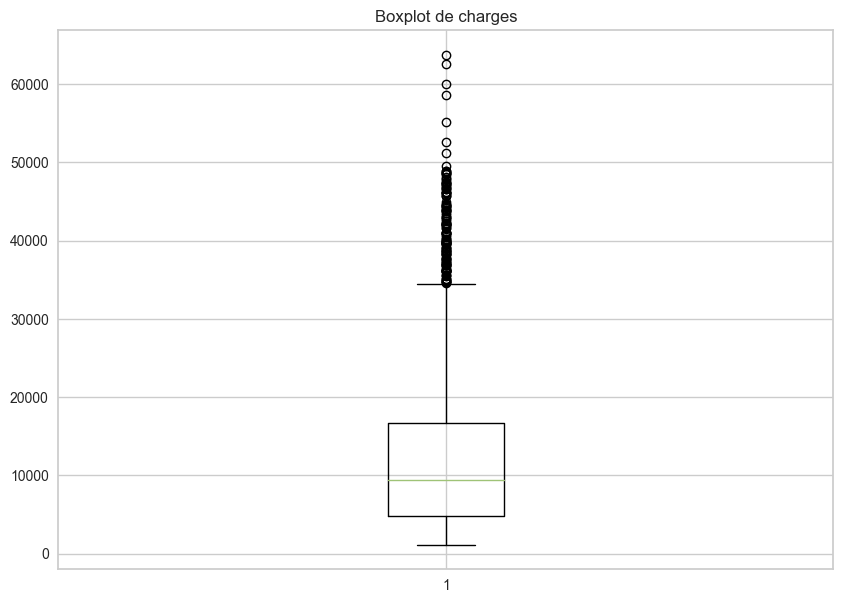

In [16]:
plt.figure(figsize=(10,7))
plt.boxplot(data['charges'])
plt.title('Boxplot de charges')
plt.show()

**Interpretation**: "D'après le boxplot, les données présentent des valeurs aberrantes. Toutefois, il est possible que certaines personnes aient des charges d'assurance supérieures à 40 000. Cela dit, une normalisation des données pourrait être nécessaire pour améliorer la modélisation."

### **III. Entraînement du modèle avec la bibliothèque PyCaret**
#### 

#### **1. Initialisation**

In [19]:
st = setup(data = data, target='charges',session_id=123,normalize=True,train_size=0.8)
# data, target : variable cible, session_id:la clé qui bloque le hasard, normalize:normalise dans même échelle les valeur

,Description,Value
0,Session id,123
1,Target,charges
2,Target type,Regression
3,Original data shape,"(1337, 7)"
4,Transformed data shape,"(1337, 10)"
5,Transformed train set shape,"(1069, 10)"
6,Transformed test set shape,"(268, 10)"
7,Numeric features,3
8,Categorical features,3
9,Preprocess,True


**Intérpretation**: 
> Dans ce tableau, nous observons que 70 % des données ont été utilisées pour entraîner le modèle, tandis que 30 % ont servi à le tester afin d’évaluer ses performances.  
> Dans ce cas, il s’agit d’un problème de régression, où l’objectif est de prédire le montant des charges d’assurance d’une personne.


#### **2. Comparaison entre différents modèles**

In [20]:
best_model = compare_models(include=['gbr','par'])
# gbr : Gradient Boosting Regressor
# par : Passive Aggressive Regressor

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2710.6032,22909252.5036,4765.5588,0.8332,0.4385,0.3164,1.3890
par,Passive Aggressive Regressor,3740.2858,52093621.6597,7169.7313,0.6233,0.4770,0.2222,0.1170


**Intérpretation**:
> Il est clair que l’algorithme Gradient Boosting Regressor est le meilleur, car il obtient les meilleures performances sur l’ensemble des métriques.  
> Ainsi, nous choisissons cet algorithme pour réaliser la modélisation finale.


#### **3. Création de modèle**

In [21]:
# model = create_model(best_model)
model = create_model('gbr')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2797.7828,24917308.9528,4991.7240,0.7887,0.4372,0.3395
1,2512.6386,21312259.3361,4616.5203,0.8666,0.4061,0.3014
2,2761.7419,22173643.4504,4708.8898,0.8732,0.4437,0.3254
3,2462.6993,17246971.9700,4152.9474,0.8689,0.4651,0.3615
4,2679.4377,19011147.3213,4360.1774,0.8072,0.4151,0.3397
5,2829.0813,26110644.6150,5109.8576,0.7943,0.5202,0.3174
6,2812.8151,24304144.8222,4929.9234,0.7718,0.4001,0.3132
7,2754.0931,25512325.8558,5050.9728,0.8675,0.4409,0.2850
8,2339.2920,16957286.6628,4117.9226,0.8998,0.3730,0.3000


#### **4. Optimisation des hyperparamètres**

In [23]:
tuned = tune_model(model)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3406.9013,28401178.2026,5329.2756,0.7591,0.5480,0.4659
1,3377.2225,28015096.7426,5292.9289,0.8247,0.7007,0.4118
2,3298.2016,32006094.4463,5657.3929,0.8170,0.6638,0.3867
3,3408.3063,29840424.4760,5462.6390,0.7732,0.7136,0.6854
4,3520.4627,31379832.6574,5601.7705,0.6817,0.5818,0.5367
5,3713.2176,40759208.4411,6384.2939,0.6789,0.7324,0.4302
6,3683.8163,33990302.7759,5830.1203,0.6809,0.5011,0.4148
7,3495.7956,29845242.5062,5463.0799,0.8450,0.7094,0.4472
8,3120.9705,24008057.2119,4899.8018,0.8581,0.5996,0.4786


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


#### **5. Evaluation de modèle**

In [ ]:
evaluate_model(tuned)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### **6. Analyse graphique des performances du modèle**

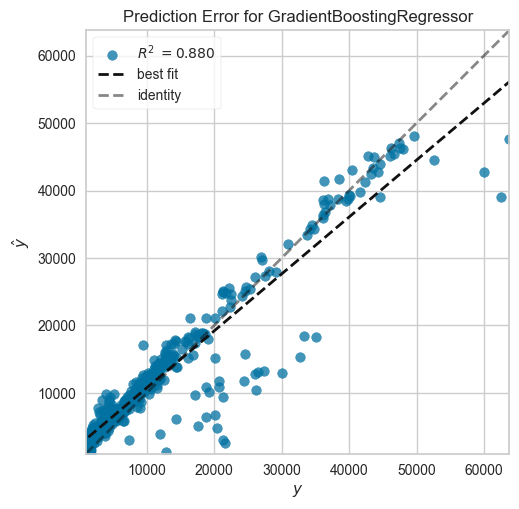

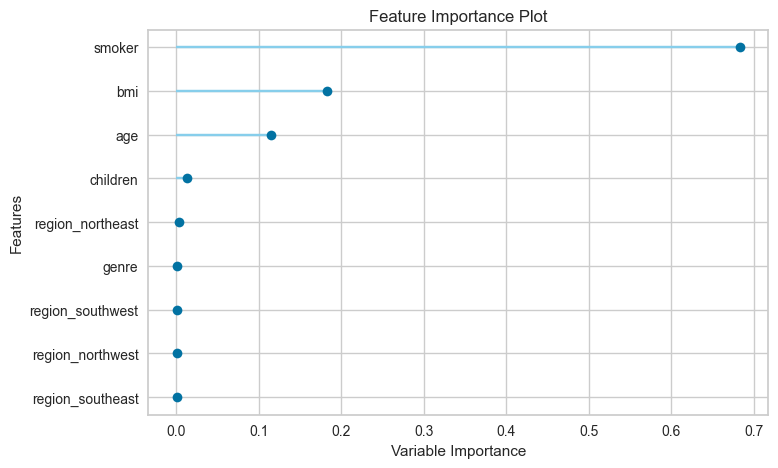

In [48]:
plot_model(tuned,plot='error')
plot_model(tuned,plot='feature')

#### **7. Finalisation de l’entraînement du modèle**

In [25]:
finalize_model(tuned)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['age', 'bmi', 'children'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['genre', 'smoker', 'region'],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('ordinal_encoding',
                 TransformerWrapper(include=['genre', 'smoker'],
                                    tran...
                                                                        {'col': 'smoker',
                                                                         'data_type': dtype('O'),
                                                                         'mapping': no     0
yes    1
NaN   -1
dtype: int64}]))),
                ('onehot_encoding',
                 TransformerWrapper(include=['region'],
                                    transformer=OneHotEncoder(cols=['region'],
                                                              handle_missing='return_nan',
                                                              use_cat_names=True))),
                ('normalize', TransformerWrapper(transformer=StandardScaler())),
                ('actual_estimator',
                 GradientBoostingRegressor(random_state=123))])

#### **8. Prédiction dan une nouvelle donnée**

In [26]:
new_data =  pd.DataFrame({
    "age": [25, 45, 32, 51, 40],
    "genre": ["female", "male", "female", "male", "female"],
    "bmi": [28.5, 33.2, 24.1, 29.9, 35.7],
    "children": [0, 2, 1, 3, 0],
    "smoker": ["no", "yes", "no", "no", "yes"],
    "region": ["southeast", "northwest", "southwest", "northeast", "southeast"],
})
new_data


,age,genre,bmi,children,smoker,region
0,25,female,28.5,0,no,southeast
1,45,male,33.2,2,yes,northwest
2,32,female,24.1,1,no,southwest
3,51,male,29.9,3,no,northeast
4,40,female,35.7,0,yes,southeast


In [27]:
predict_model(tuned,data = new_data)

,age,genre,bmi,children,smoker,region,prediction_label
0,25,female,28.500000,0,no,southeast,4318.417037
1,45,male,33.200001,2,yes,northwest,42276.919342
2,32,female,24.100000,1,no,southwest,5534.255809
3,51,male,29.900000,3,no,northeast,12187.316107
4,40,female,35.700001,0,yes,southeast,40103.553250


#### **9. Sauvegarde de modèle**

In [28]:
save_model(tuned,'../model/modele_regression')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['age', 'bmi', 'children'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=['genre', 'smoker', 'region'],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('ordinal_encoding',
                  TransformerWrapper(include=['genre', 'smoker'],
                                     tran...
                                                                         {'col': 'smoker',
                                                                          'data_type': dtype('O'),
                                                                          'mapping': no     0
 yes    1
 NaN   -1
 dtype: int64}]))),
                 ('onehot_encoding',
                  TransformerWrapper(include=['region'],
    